In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from deeperfly import multiview_geom as mvg


def get_rmat(yaw):
    y = np.array([0, 0, -1])
    z = np.array([-np.cos(yaw), -np.sin(yaw), 0])
    return np.array([np.cross(y, z), y, z])


f = 22388.125
f_mm = 107.463
w = 1024
h = 512
cx = (w - 1) / 2
cy = (h - 1) / 2
azimuths_deg = [-120, -90, -45, 0, 45, 90, 120]

In [3]:
intr_gt = np.array([f, cx, cy])
rmats_gt = np.array([get_rmat(theta) for theta in np.deg2rad(azimuths_deg)])
tvecs_gt = np.array([[0, 0, f_mm]] * len(rmats_gt), dtype=float)
pts3d_gt = np.random.default_rng(0).uniform(-0.5, 0.5, size=(100, 3))
rvecs_gt = mvg.rmat2vec(rmats_gt)
dist_gt = np.array((), dtype=float)

In [4]:
pts2d_cv2, jac = mvg.project_full_cv2(pts3d_gt, rvecs_gt, tvecs_gt, intr_gt, dist_gt)

In [5]:
pts2d_gt = mvg.project_full(pts3d_gt, rvecs_gt, tvecs_gt, intr_gt, dist_gt)

In [6]:
np.allclose(pts2d_cv2, pts2d_gt)

True

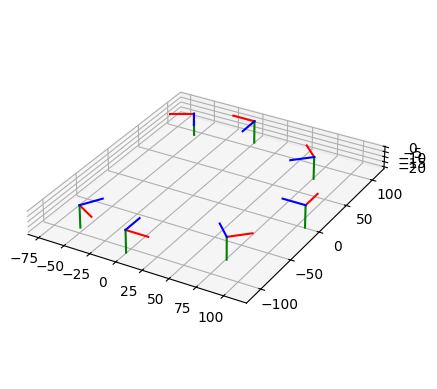

In [7]:
def plot_camera(rmat, tvec, ax3d, length=None):
    center = -rmat.T @ tvec
    if length is None:
        length = np.linalg.norm(tvec) * 0.2
    for i, c in enumerate("rgb"):
        ax3d.plot(*zip(center, center + rmat[i] * length), c=c)


fig, ax3d = plt.subplots(subplot_kw={"projection": "3d"})
for rmat, tvec in zip(rmats_gt, tvecs_gt):
    plot_camera(rmat, tvec, ax3d)
ax3d.set_aspect("equal")

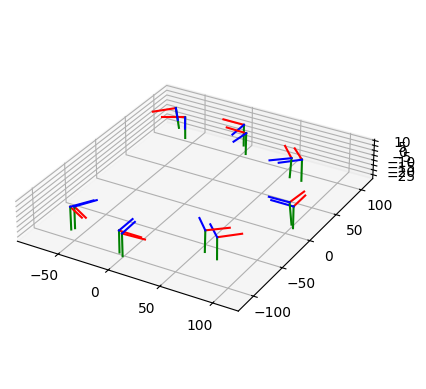

In [8]:
import numpy as np


def small_rotation(sigma=1e-3, seed=None):
    from scipy.linalg import expm

    rng = np.random.default_rng(seed)
    omega = rng.normal(scale=sigma, size=3)  # small rotation vector
    K = np.array(
        [[0, -omega[2], omega[1]], [omega[2], 0, -omega[0]], [-omega[1], omega[0], 0]]
    )
    return expm(K)


rmats0 = np.array([small_rotation(0.05, i) @ rmat for i, rmat in enumerate(rmats_gt)])
tvecs0 = tvecs_gt + np.random.default_rng(0).normal(scale=5, size=tvecs_gt.shape)
rvecs0 = mvg.rmat2vec(rmats0)

fig, ax3d = plt.subplots(subplot_kw={"projection": "3d"})
for rmat, tvec in zip(rmats_gt, tvecs_gt):
    plot_camera(rmat, tvec, ax3d)
for rmat, tvec in zip(rmats0, tvecs0):
    plot_camera(rmat, tvec, ax3d)
ax3d.set_aspect("equal")

In [9]:
from deeperfly import bundle_adjustment as nba
from deeperfly import bundle_adjustment_jax

In [ ]:
res, (rvecs_opt, tvecs_opt, intrs_opt, dists_opt, pts3d_opt) = (
    bundle_adjustment_jax.bundle_adjust(
        *nba.prep_args(rvecs0, tvecs0, intr_gt, dist_gt, pts2d_gt)
    )
)

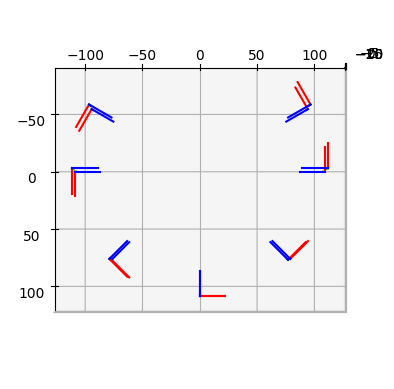

In [11]:
# from deeperfly import new_bundle_adjustment as nba
from deeperfly import multiview_geom as mvg

# Align the optimized system to ground truth using camera 3 as the anchor.
# A rigid world transform X_new = R_a @ X_old + t_a induces
#   R_i' = R_i @ R_a.T,  t_i' = t_i - R_i' @ t_a
# Solving R_3' = R_gt[3], t_3' = t_gt[3] gives the values below.
rmats_opt = mvg.rvec2mat(rvecs_opt)

R_a = rmats_gt[3].T @ rmats_opt[3]
t_a = rmats_gt[3].T @ (tvecs_opt[3] - tvecs_gt[3])

rmats_opt = rmats_opt @ R_a.T
tvecs_opt = tvecs_opt - np.einsum("oij,j->oi", rmats_opt, t_a)
pts3d_opt = pts3d_opt @ R_a.T + t_a


fig, ax3d = plt.subplots(subplot_kw={"projection": "3d"})
for rmat, tvec in zip(rmats_gt, tvecs_gt):
    plot_camera(rmat, tvec, ax3d)
for rmat, tvec in zip(rmats_opt, tvecs_opt):
    plot_camera(rmat, tvec, ax3d)
ax3d.set_aspect("equal")
ax3d.view_init(elev=90, azim=0)

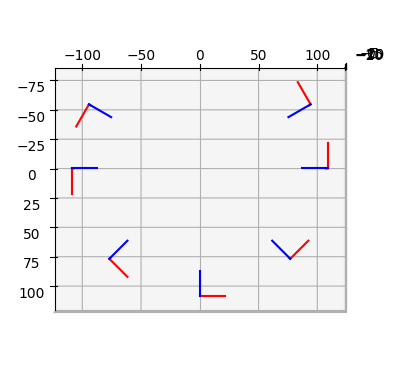

In [12]:
fig, ax3d = plt.subplots(subplot_kw={"projection": "3d"})
for rmat, tvec in zip(rmats_gt, tvecs_gt):
    plot_camera(rmat, tvec, ax3d)
ax3d.set_aspect("equal")
ax3d.view_init(elev=90, azim=0)

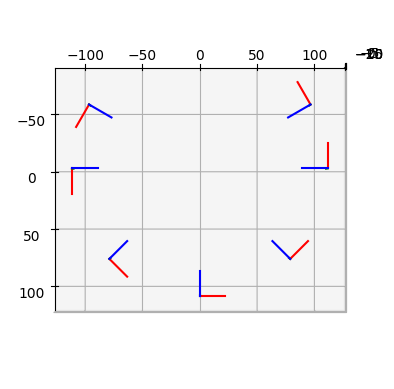

In [13]:
fig, ax3d = plt.subplots(subplot_kw={"projection": "3d"})
for rmat, tvec in zip(rmats_opt, tvecs_opt):
    plot_camera(rmat, tvec, ax3d)
ax3d.set_aspect("equal")
ax3d.view_init(elev=90, azim=0)